In [44]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar



In [30]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="swar@123",
    database="project"
)

print("Connected successfully")

Connected successfully


In [15]:
cursor = conn.cursor()


In [58]:
cursor.execute("SHOW TABLES;")
tables = cursor.fetchall()
tables

[('customers',),
 ('geolocation',),
 ('order_items',),
 ('orders',),
 ('payments',),
 ('products',),
 ('sellers',)]

In [75]:
#3. total sales per category 
query=" SELECT  p.product_category AS category, SUM(oi.price) AS total_sales FROM order_items oi JOIN products p ON oi.product_id = p.product_id GROUP BY p.product_category ORDER BY total_sales DESC"
sales_df=pd.read_sql(query,conn)
df


C:\Users\Hp\AppData\Local\Temp\ipykernel_348\934668779.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df=pd.read_sql(query,conn)


,seller_id,total_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
1,53243585a1d6dc2643021fd1853d8905,222776.05
2,4a3ca9315b744ce9f8e9374361493884,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,187923.89
...,...,...
3090,34aefe746cd81b7f3b23253ea28bef39,8.00
3091,702835e4b785b67a084280efca355756,7.60
3092,1fa2d3def6adfa70e58c276bb64fe5bb,6.90
3093,77128dec4bec4878c37ab7d6169d6f26,6.50


In [46]:
order_items = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')

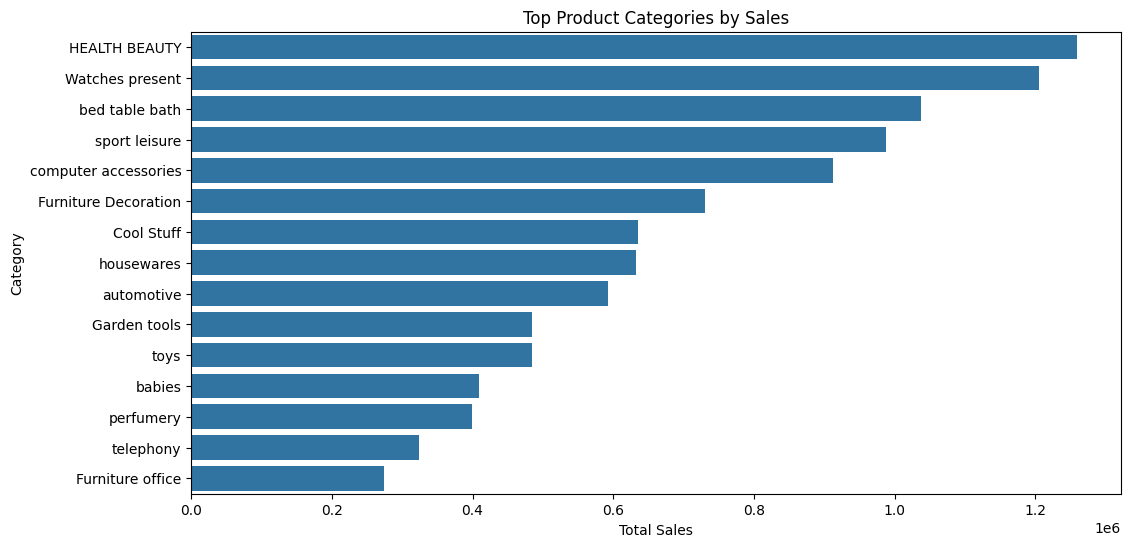

In [77]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sales_df.head(15),
    x='total_sales',
    y='category'
)

plt.title("Top Product Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.show()


In [65]:
#2 monthly sales trend
query=""" SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    SUM(oi.price) AS revenue
FROM orders o
JOIN order_items oi
ON o.order_id = oi.order_id
GROUP BY month
ORDER BY month;"""
sales_df=pd.read_sql(query,conn)
df


C:\Users\Hp\AppData\Local\Temp\ipykernel_348\1333291962.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df=pd.read_sql(query,conn)


,product_id,product_category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00066f42aeeb9f3007548bb9d3f33c38,perfumery,53,596,6,300,20,16,16
1,00088930e925c41fd95ebfe695fd2655,automotive,56,752,4,1225,55,10,26
2,0009406fd7479715e4bef61dd91f2462,bed table bath,50,266,2,300,45,15,35
3,000b8f95fcb9e0096488278317764d19,housewares,25,364,3,550,19,24,12
4,000d9be29b5207b54e86aa1b1ac54872,Watches present,48,613,4,250,22,11,15
...,...,...,...,...,...,...,...,...,...
32335,fff6177642830a9a94a0f2cba5e476d1,Cool Stuff,54,842,1,1400,42,25,15
32336,fff81cc3158d2725c0655ab9ba0f712c,HEALTH BEAUTY,54,643,1,58,16,16,11
32337,fff9553ac224cec9d15d49f5a263411f,Fashion Bags and Accessories,22,328,3,150,16,13,11
32338,fffdb2d0ec8d6a61f0a0a0db3f25b441,computer accessories,47,501,5,150,16,4,13


In [66]:
monthly_sales = pd.read_sql(query2, conn)


C:\Users\Hp\AppData\Local\Temp\ipykernel_348\3748791195.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_sales = pd.read_sql(query2, conn)


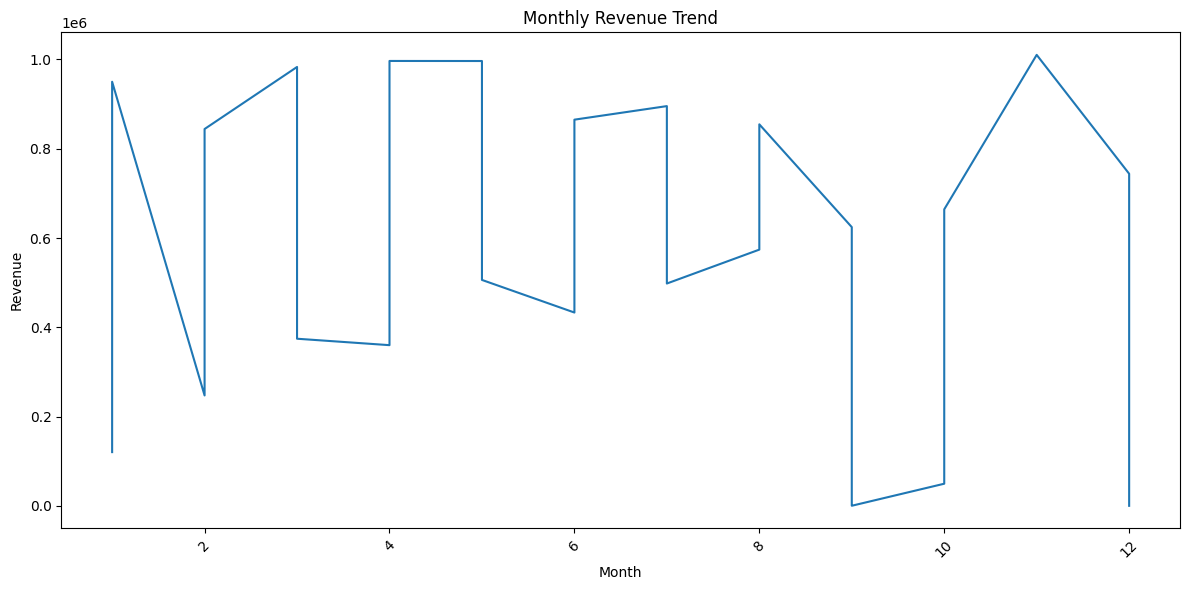

In [68]:
monthly_sales = monthly_sales.sort_values('month')

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['month'], monthly_sales['revenue'])
plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [70]:
#3 seller revenue ranking 
query4="""SELECT 
    seller_id,
    SUM(price) AS total_revenue
FROM order_items
GROUP BY seller_id
ORDER BY total_revenue DESC;"""
df=pd.read_sql(query4,conn)
df
               

C:\Users\Hp\AppData\Local\Temp\ipykernel_348\580120438.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query4,conn)


,seller_id,total_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
1,53243585a1d6dc2643021fd1853d8905,222776.05
2,4a3ca9315b744ce9f8e9374361493884,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,187923.89
...,...,...
3090,34aefe746cd81b7f3b23253ea28bef39,8.00
3091,702835e4b785b67a084280efca355756,7.60
3092,1fa2d3def6adfa70e58c276bb64fe5bb,6.90
3093,77128dec4bec4878c37ab7d6169d6f26,6.50


C:\Users\Hp\AppData\Local\Temp\ipykernel_348\2226398327.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  seller_rev = pd.read_sql(query4, conn)


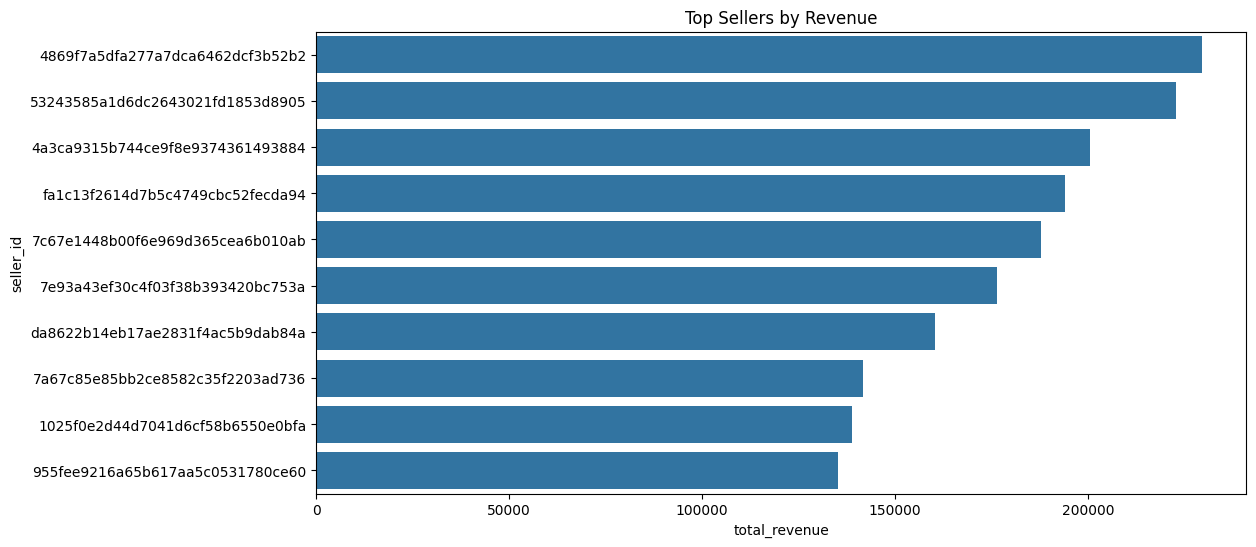

In [71]:
seller_rev = pd.read_sql(query4, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=seller_rev.head(10),
            x='total_revenue',
            y='seller_id')

plt.title("Top Sellers by Revenue")
plt.show()

In [4]:
#average number of products per order, grouped by customer city
query5="""SELECT 
    c.customer_city,
    AVG(order_product_count) AS avg_products_per_order
FROM
    (SELECT 
        o.order_id,
            o.customer_id,
            COUNT(oi.product_id) AS order_product_count
    FROM
        orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY o.order_id , o.customer_id) t
        JOIN
    customers c ON t.customer_id = c.customer_id
GROUP BY c.customer_city
ORDER BY avg_products_per_order DESC;"""
df=pd.read_sql(query5,conn)
df


C:\Users\Hp\AppData\Local\Temp\ipykernel_13376\3720368022.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query5,conn)


,customer_city,avg_products_per_order
0,padre carvalho,7.0
1,celso ramos,6.5
2,candido godoi,6.0
3,datas,6.0
4,matias olimpio,5.0
...,...,...
4105,pianco,1.0
4106,arantina,1.0
4107,padre paraiso,1.0
4108,vitoria do jari,1.0


In [5]:
avg_products_df = pd.read_sql(query5, conn)


C:\Users\Hp\AppData\Local\Temp\ipykernel_13376\2004505663.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  avg_products_df = pd.read_sql(query5, conn)


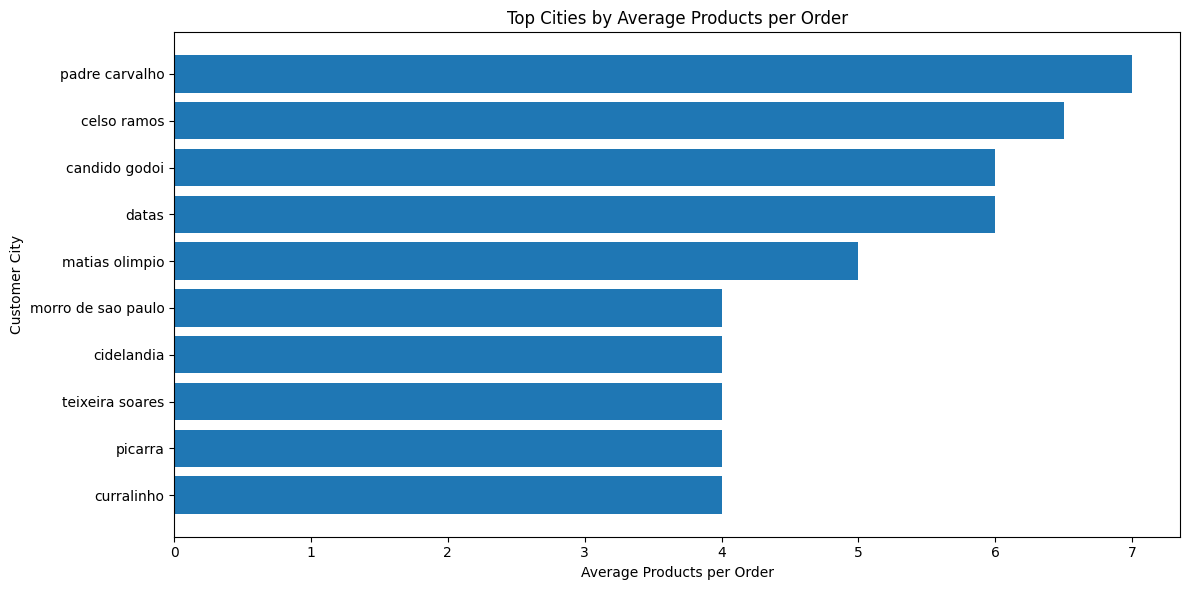

In [6]:
top_cities = avg_products_df.head(10)

plt.figure(figsize=(12,6))
plt.barh(top_cities['customer_city'], top_cities['avg_products_per_order'])

plt.title("Top Cities by Average Products per Order")
plt.xlabel("Average Products per Order")
plt.ylabel("Customer City")

plt.gca().invert_yaxis()   # highest value on top
plt.tight_layout()
plt.show()

In [24]:
#8️⃣Revenue % per category
query6="""SELECT 
    p.product_category AS category,
    SUM(oi.price) AS category_revenue,
    ROUND(SUM(oi.price) * 100.0 / (SELECT 
                    SUM(price)
                FROM
                    order_items),
            2) AS revenue_percentage
FROM
    order_items oi
        JOIN
    products p ON oi.product_id = p.product_id
GROUP BY p.product_category
ORDER BY revenue_percentage DESC;
#4 Identify the correlation between product price and the number of times a product has been purchased
SELECT 
    oi.product_id,
    AVG(oi.price) AS avg_price,
    COUNT(oi.product_id) AS purchase_count
FROM order_items oi
GROUP BY oi.product_id;"""
category_revenue_df=pd.read_sql(query6,conn)
category_revenue_df

C:\Users\Hp\AppData\Local\Temp\ipykernel_13376\386232658.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_revenue_df=pd.read_sql(query6,conn)


,category,category_revenue,revenue_percentage
0,HEALTH BEAUTY,1258681.34,9.26
1,Watches present,1205005.68,8.87
2,bed table bath,1036988.68,7.63
3,sport leisure,988048.97,7.27
4,computer accessories,911954.32,6.71
...,...,...,...
68,Arts and Crafts,1814.01,0.01
69,House Comfort 2,760.27,0.01
70,PC Gamer,1545.95,0.01
71,insurance and services,283.29,0.00


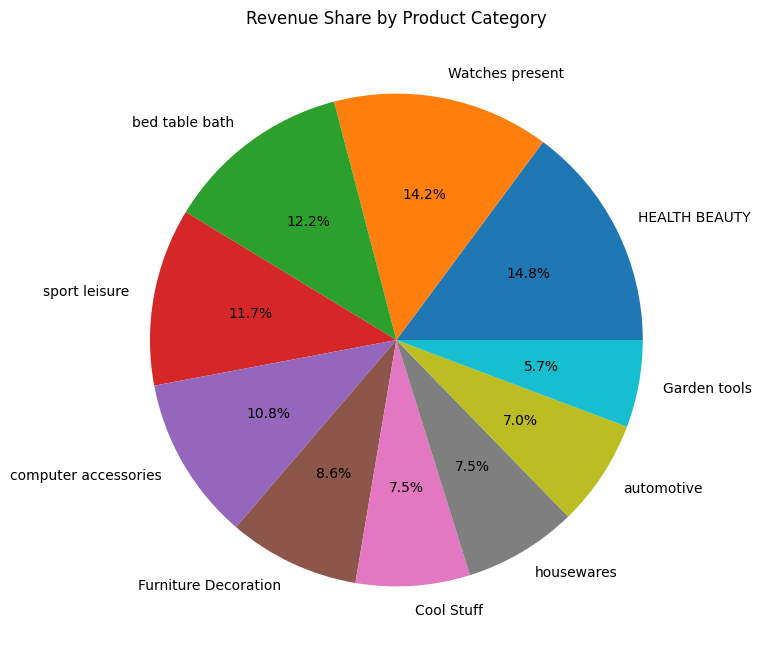

In [28]:
plt.figure(figsize=(8,8))
plt.pie(
    top_categories['revenue_percentage'],
    labels=top_categories['category'],
    autopct='%1.1f%%'
)

plt.title("Revenue Share by Product Category")
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_13376\1874608029.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  moving_df=pd.read_sql(query7,conn)


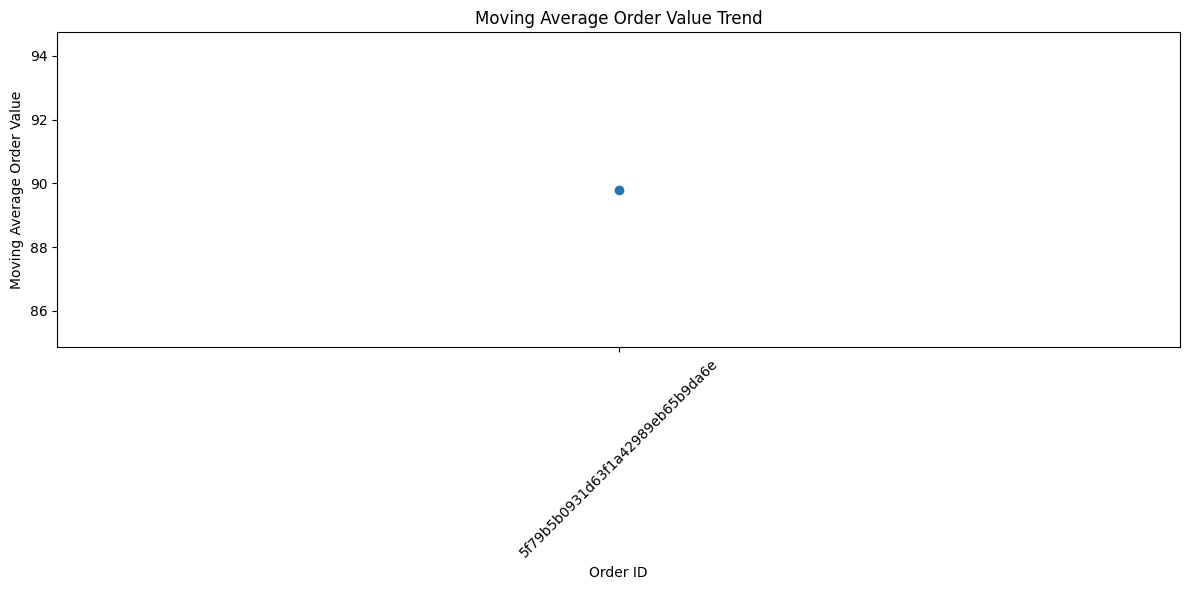

In [41]:
#  moving average
query7="""SELECT o.customer_id, o.order_id, SUM(oi.price) AS order_value,
AVG(SUM(oi.price)) OVER (PARTITION BY o.customer_id ORDER BY o.order_purchase_timestamp ROWS 2 PRECEDING) AS moving_avg
FROM orders o JOIN order_items oi ON o.order_id=oi.order_id
GROUP BY o.customer_id,o.order_id,o.order_purchase_timestamp;"""
moving_df=pd.read_sql(query7,conn)
moving_df
moving_df['customer_id'].value_counts().head(50)
# choose customer with most orders
top_customer = moving_df['customer_id'].value_counts().idxmax()

cust_data = moving_df[moving_df['customer_id'] == top_customer]
cust_data = cust_data.sort_values('order_id')

plt.figure(figsize=(12,6))
plt.plot(cust_data['order_id'], cust_data['moving_avg'], marker='o')

plt.title("Moving Average Order Value Trend")
plt.xlabel("Order ID")
plt.ylabel("Moving Average Order Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [42]:
moving_df['customer_id'].value_counts().head(10)


customer_id
00012a2ce6f8dcda20d059ce98491703    1
000161a058600d5901f007fab4c27140    1
0001fd6190edaaf884bcaf3d49edf079    1
0002414f95344307404f0ace7a26f1d5    1
000379cdec625522490c315e70c7a9fb    1
0004164d20a9e969af783496f3408652    1
000419c5494106c306a97b5635748086    1
00046a560d407e99b969756e0b10f282    1
00050bf6e01e69d5c0fd612f1bcfb69c    1
000598caf2ef4117407665ac33275130    1
Name: count, dtype: int64

C:\Users\Hp\AppData\Local\Temp\ipykernel_13376\502204919.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_df=pd.read_sql(query8,conn)


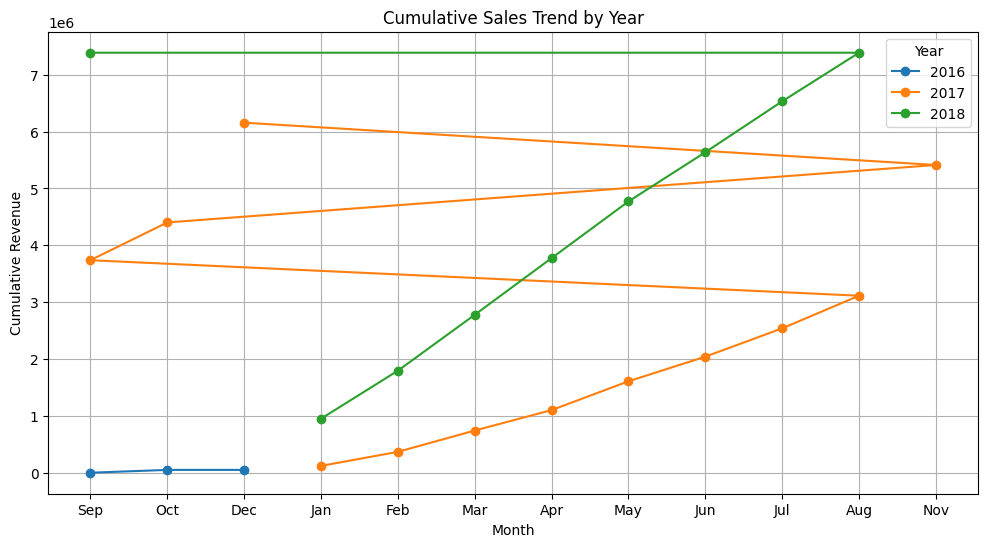

In [46]:
query8="""SELECT 
    YEAR(o.order_purchase_timestamp) AS year,
    MONTH(o.order_purchase_timestamp) AS month,
    SUM(oi.price) AS monthly_sales,
    SUM(SUM(oi.price)) OVER (
        PARTITION BY YEAR(o.order_purchase_timestamp)
        ORDER BY MONTH(o.order_purchase_timestamp)
    ) AS cumulative_sales
FROM orders o
JOIN order_items oi 
    ON o.order_id = oi.order_id
GROUP BY YEAR(o.order_purchase_timestamp), MONTH(o.order_purchase_timestamp)
ORDER BY year, month;"""
sales_df=pd.read_sql(query8,conn)
sales_df
plt.figure(figsize=(12,6))
sales_df['month_name'] = sales_df['month'].apply(lambda x: calendar.month_abbr[x])

for year in sales_df['year'].unique():
    yearly_data = sales_df[sales_df['year'] == year]
    
    plt.plot(
        yearly_data['month_name'],
        yearly_data['cumulative_sales'],
        marker='o',
        label=year
    )

plt.title("Cumulative Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Cumulative Revenue")

plt.legend(title="Year")
plt.grid(True)
plt.show()


In [ ]:
#YOY grpwth
query9="""SELECT 
    year,
    total_sales,
    LAG(total_sales) OVER (ORDER BY year) AS previous_year_sales,
    ROUND(
        (total_sales - LAG(total_sales) OVER (ORDER BY year)) * 100 
        / LAG(total_sales) OVER (ORDER BY year),
        2
    ) AS yoy_growth_percentage
FROM (
    SELECT 
        YEAR(o.order_purchase_timestamp) AS year,
        SUM(oi.price) AS total_sales
    FROM orders o
    JOIN order_items oi 
        ON o.order_id = oi.order_id
    GROUP BY YEAR(o.order_purchase_timestamp)
) t
ORDER BY year;"""
